# DAIC-WOZ Video Feature Analysis: Head Movement and Blink Patterns

This notebook performs an exploratory analysis of video-derived features from the DAIC-WOZ dataset, focusing on head movement velocity (translational and rotational) and blink patterns. It calculates and visualizes these features over time for different participants, aiming to identify potential indicators related to depression. The analysis includes outlier handling, windowed aggregation, and smoothing of velocity data, as well as a custom function to extract blink statistics (count, rate, and average duration) per minute.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = "/content/drive/MyDrive/DAIC_WOZ_VIDEO_BRANCH/data"
DATA_DIR = f"{BASE_DIR}/processed/new_processed"
LABELS = f"{BASE_DIR}/labels/labels_train_dev_clean.csv"

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
sample_300_df = pd.read_csv(f"{DATA_DIR}/300_nprocessed.csv")


In [ ]:
sample_300_df.head()

,pose_Tx,pose_Ty,pose_Tz,pose_Rx,pose_Ry,pose_Rz,gaze_0_x,gaze_0_y,gaze_0_z,gaze_1_x,...,AU12_c,AU14_c,AU15_c,AU17_c,AU20_c,AU23_c,AU25_c,AU26_c,AU28_c,AU45_c
0,69.5,37.7,576.8,0.221,0.036,-0.068,0.015324,0.298824,-0.954185,-0.187119,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,69.4,37.4,577.5,0.219,0.037,-0.067,0.006174,0.294520,-0.955626,-0.191460,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,69.4,37.3,576.7,0.223,0.039,-0.069,0.005192,0.298043,-0.954538,-0.193294,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,69.3,37.3,576.5,0.225,0.039,-0.069,0.005523,0.299662,-0.954030,-0.192734,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,69.4,37.3,576.6,0.225,0.039,-0.070,0.005461,0.300506,-0.953764,-0.192661,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
import numpy as np

def aggregate_velocity(df, fps=30):

    dt = 1 / fps

    # Translation coordinates
    T = df[["pose_Tx", "pose_Ty", "pose_Tz"]].values

    # Difference between consecutive frames
    dT = np.diff(T, axis=0)

    # Velocity vectors
    velocity_vectors = dT / dt

    # Magnitude of velocity at each frame
    frame_velocity = np.linalg.norm(velocity_vectors, axis=1)

    # Aggregate
    aggregated_velocity = np.mean(frame_velocity)


    return frame_velocity, aggregated_velocity

In [ ]:
def aggregate_rotational_velocity(df, fps=30):

    dt = 1 / fps

    R = df[["pose_Rx","pose_Ry","pose_Rz"]].values

    dR = np.diff(R, axis=0)

    angular_velocity = dR / dt

    frame_rot_velocity = np.linalg.norm(angular_velocity, axis=1)

    aggregated_rot_velocity = np.mean(frame_rot_velocity)

    return frame_rot_velocity, aggregated_rot_velocity

In [ ]:
frame_velocity, avg_velocity = aggregate_velocity(sample_303_df)
frame_rot_velocity,avg_rot_velocity = aggregate_rotational_velocity(sample_303_df)
print(frame_velocity)
print(avg_velocity)
print(frame_rot_velocity)
print(avg_rot_velocity)


[ 87.51571287   3.           3.         ... 129.86916493 136.35981813
 198.47669888]
48.602165306613266
[0.2034699  0.09       0.06       ... 0.35623026 0.3923009  0.40914545]
0.2926456656036774


In [ ]:
import numpy as np

# Copy original velocity array
clean_velocity = frame_velocity.copy()

# Threshold for outliers
threshold = 1000

# Indices of outliers
outliers = np.where(clean_velocity > threshold)[0]

for idx in outliers:
    neighbors = []

    # Previous value
    if idx > 0 and clean_velocity[idx - 1] <= threshold:
        neighbors.append(clean_velocity[idx - 1])

    # Next value
    if idx < len(clean_velocity) - 1 and clean_velocity[idx + 1] <= threshold:
        neighbors.append(clean_velocity[idx + 1])

    if neighbors:
        clean_velocity[idx] = np.mean(neighbors)
    else:
        # Fallback: global median
        clean_velocity[idx] = np.median(clean_velocity[clean_velocity <= threshold])

In [ ]:
print(np.max(clean_velocity))

953.0230847151612


In [ ]:
import matplotlib.pyplot as plt

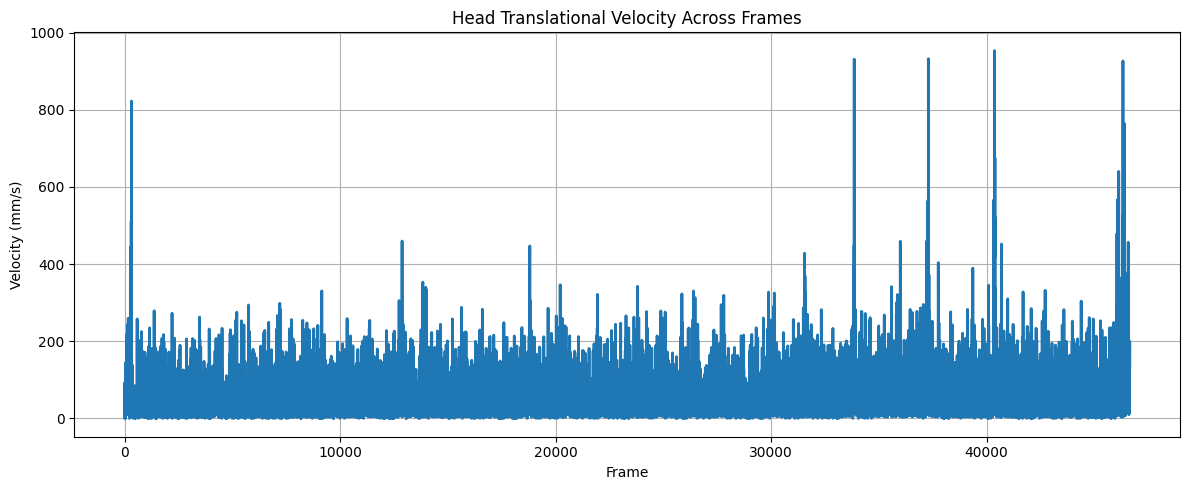

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Frame numbers corresponding to each velocity
frames = np.arange(1, len(clean_velocity) + 1)

plt.figure(figsize=(12, 5))

plt.plot(frames, clean_velocity, linewidth=2)

plt.title("Head Translational Velocity Across Frames")
plt.xlabel("Frame")
plt.ylabel("Velocity (mm/s)")
plt.grid(True)

plt.tight_layout()
plt.show()

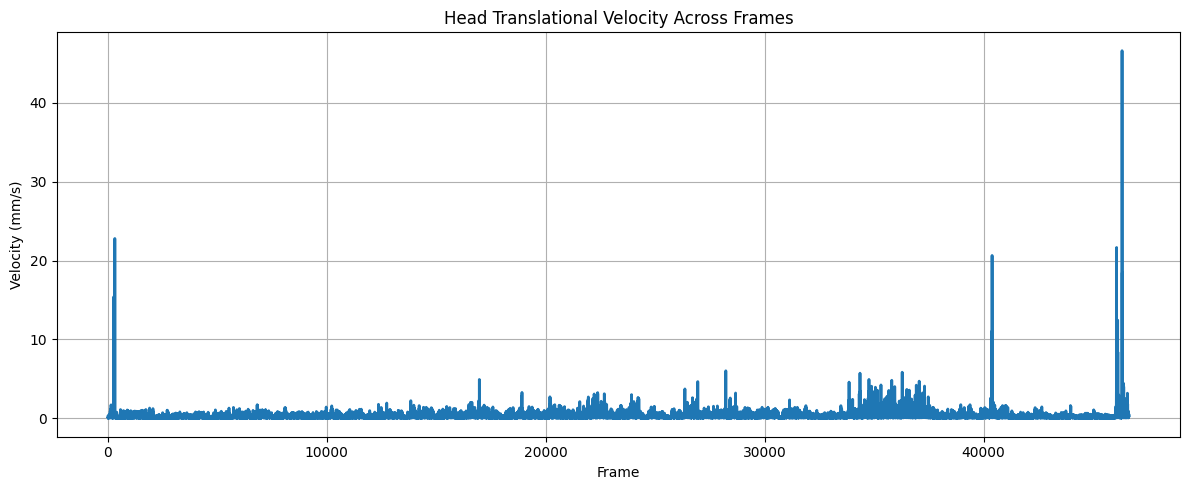

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Frame numbers corresponding to each velocity
frames = np.arange(1, len(frame_rot_velocity) + 1)

plt.figure(figsize=(12, 5))

plt.plot(frames, frame_rot_velocity, linewidth=2)

plt.title("Head Translational Velocity Across Frames")
plt.xlabel("Frame")
plt.ylabel("Velocity (mm/s)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

window_size = 150

window_mean_velocity = []

for start in range(0, len(clean_velocity), window_size):
    window = clean_velocity[start:start + window_size]

    # Ignore empty windows
    if len(window) > 0:
        window_mean_velocity.append(np.mean(window))

window_mean_velocity = np.array(window_mean_velocity)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

window_size = 150

window_mean_rot_velocity = []

for start in range(0, len(frame_rot_velocity), window_size):
    window = frame_rot_velocity[start:start + window_size]

    # Ignore empty windows
    if len(window) > 0:
        window_mean_rot_velocity.append(np.mean(window))

window_mean_rot_velocity = np.array(window_mean_rot_velocity)

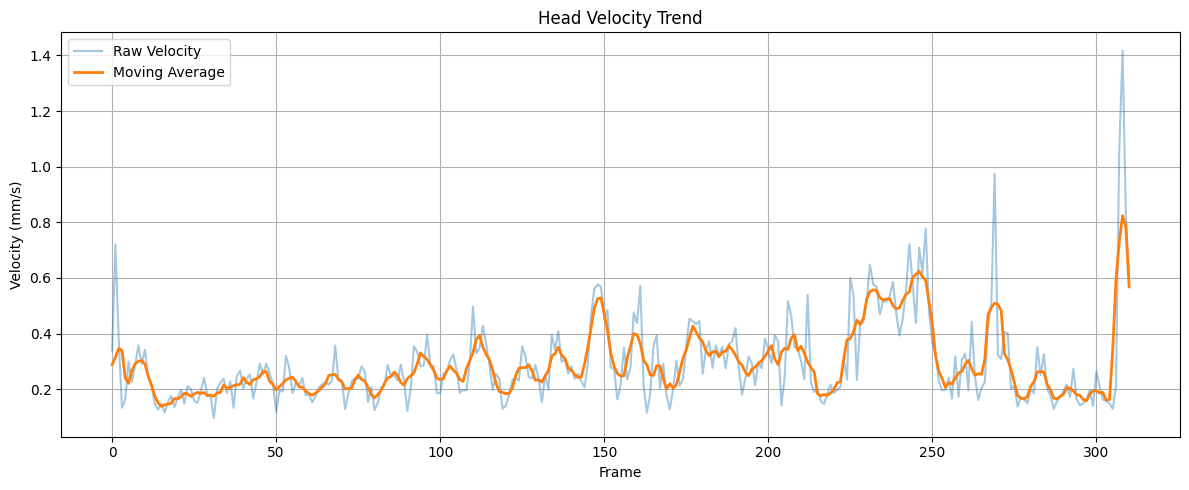

In [ ]:
window = 5

smooth_velocity = np.convolve(
    window_mean_rot_velocity,
    np.ones(window) / window,
    mode="same"
)

plt.figure(figsize=(12,5))

plt.plot(window_mean_rot_velocity, alpha=0.4, label="Raw Velocity")
plt.plot(smooth_velocity, linewidth=2, label="Moving Average")

plt.xlabel("Frame")
plt.ylabel("Velocity (mm/s)")
plt.title("Head Velocity Trend")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

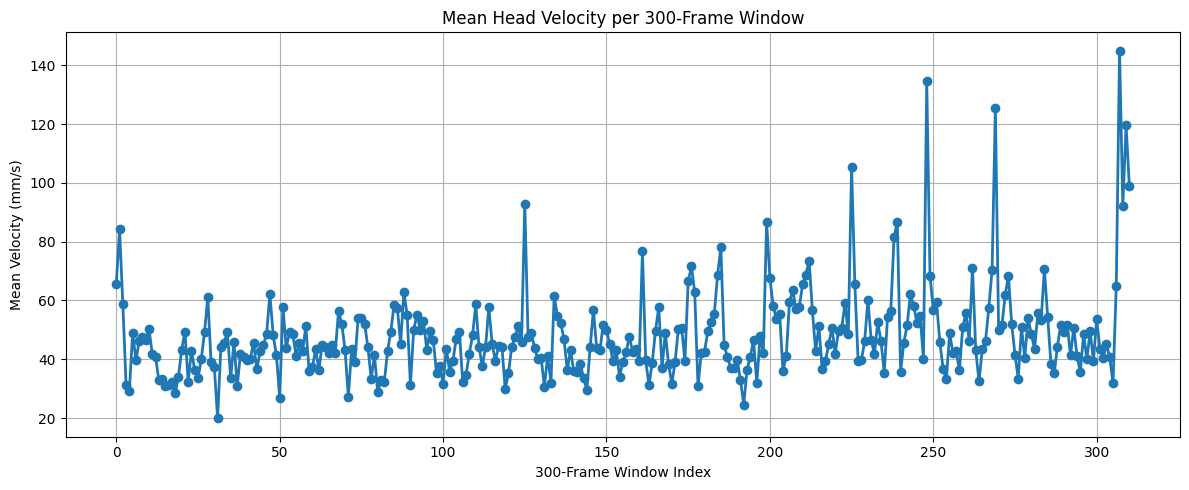

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    np.arange(len(window_mean_velocity)),
    window_mean_velocity,
    marker='o',
    linewidth=2
)

plt.title("Mean Head Velocity per 300-Frame Window")
plt.xlabel("300-Frame Window Index")
plt.ylabel("Mean Velocity (mm/s)")
plt.grid(True)

plt.tight_layout()
plt.show()

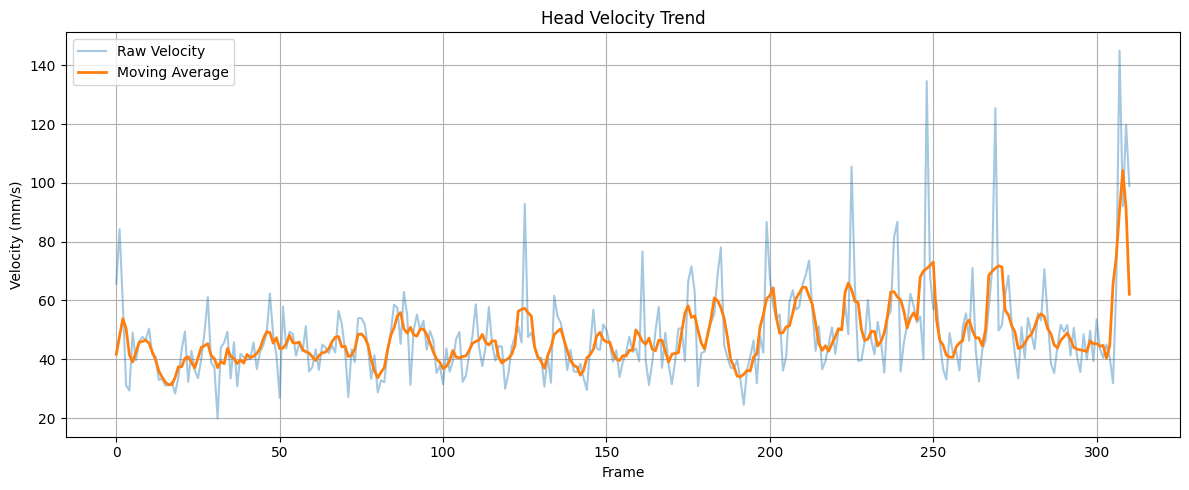

In [ ]:
window = 5

smooth_velocity = np.convolve(
    window_mean_velocity,
    np.ones(window) / window,
    mode="same"
)

plt.figure(figsize=(12,5))

plt.plot(window_mean_velocity, alpha=0.4, label="Raw Velocity")
plt.plot(smooth_velocity, linewidth=2, label="Moving Average")

plt.xlabel("Frame")
plt.ylabel("Velocity (mm/s)")
plt.title("Head Velocity Trend")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
sample_308_df = pd.read_csv(f"{DATA_DIR}/308_nprocessed.csv")

In [ ]:
frame_velocity, avg_velocity = aggregate_velocity(sample_308_df)

print(frame_velocity)
print(avg_velocity)

[155.76905983 292.38844026 471.07642692 ...  17.74823935  51.8748494
  25.8069758 ]
67.15044186318164


In [ ]:
import numpy as np

# Copy original velocity array
clean_velocity = frame_velocity.copy()

# Threshold for outliers
threshold = 1000

# Indices of outliers
outliers = np.where(clean_velocity > threshold)[0]

for idx in outliers:
    neighbors = []

    # Previous value
    if idx > 0 and clean_velocity[idx - 1] <= threshold:
        neighbors.append(clean_velocity[idx - 1])

    # Next value
    if idx < len(clean_velocity) - 1 and clean_velocity[idx + 1] <= threshold:
        neighbors.append(clean_velocity[idx + 1])

    if neighbors:
        clean_velocity[idx] = np.mean(neighbors)
    else:
        # Fallback: global median
        clean_velocity[idx] = np.median(clean_velocity[clean_velocity <= threshold])

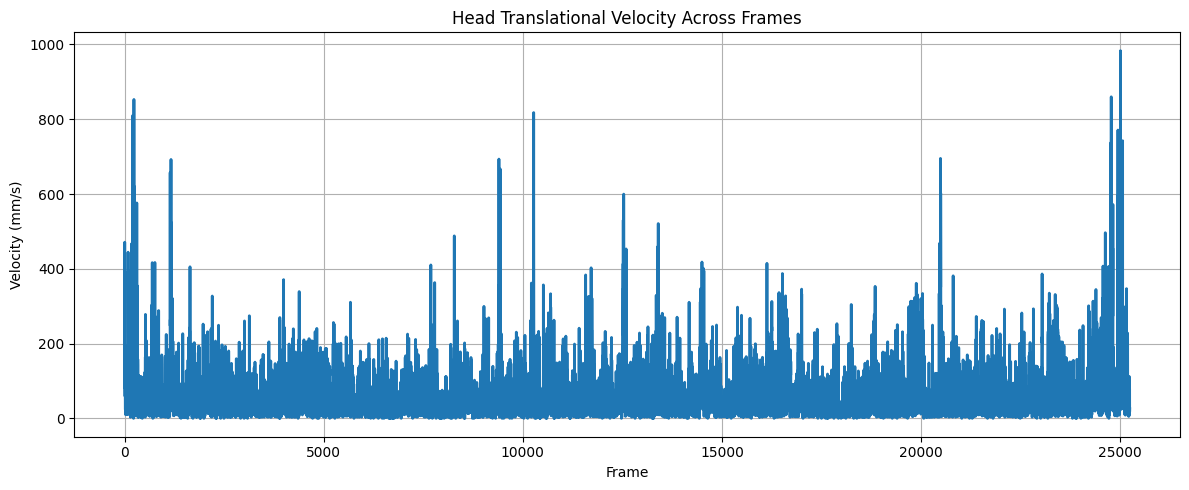

In [ ]:
# Frame numbers corresponding to each velocity
frames = np.arange(1, len(clean_velocity) + 1)

plt.figure(figsize=(12, 5))

plt.plot(frames, clean_velocity, linewidth=2)

plt.title("Head Translational Velocity Across Frames")
plt.xlabel("Frame")
plt.ylabel("Velocity (mm/s)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
window_size = 150

window_mean_velocity = []

for start in range(0, len(clean_velocity), window_size):
    window = clean_velocity[start:start + window_size]

    # Ignore empty windows
    if len(window) > 0:
        window_mean_velocity.append(np.mean(window))

window_mean_velocity = np.array(window_mean_velocity)

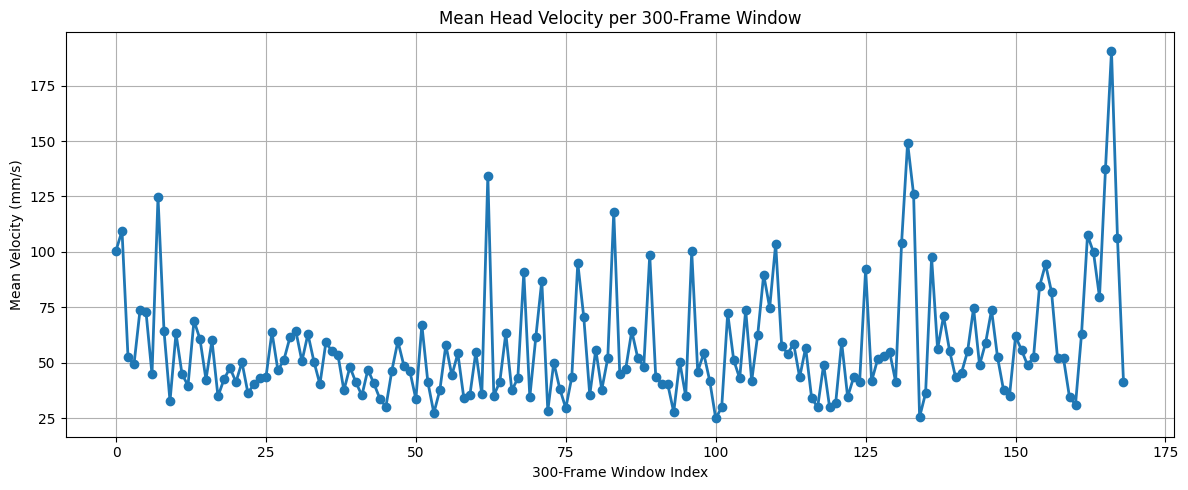

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    np.arange(len(window_mean_velocity)),
    window_mean_velocity,
    marker='o',
    linewidth=2
)

plt.title("Mean Head Velocity per 300-Frame Window")
plt.xlabel("300-Frame Window Index")
plt.ylabel("Mean Velocity (mm/s)")
plt.grid(True)

plt.tight_layout()
plt.show()

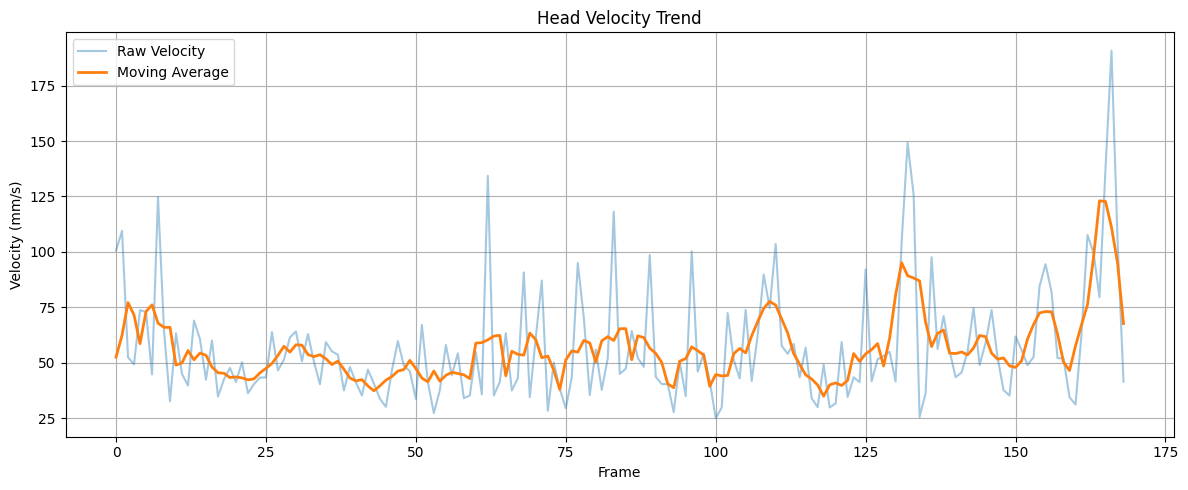

In [ ]:
window = 5

smooth_velocity = np.convolve(
    window_mean_velocity,
    np.ones(window) / window,
    mode="same"
)

plt.figure(figsize=(12,5))

plt.plot(window_mean_velocity, alpha=0.4, label="Raw Velocity")
plt.plot(smooth_velocity, linewidth=2, label="Moving Average")

plt.xlabel("Frame")
plt.ylabel("Velocity (mm/s)")
plt.title("Head Velocity Trend")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
sample_348_df = pd.read_csv(f"{DATA_DIR}/348_nprocessed.csv")

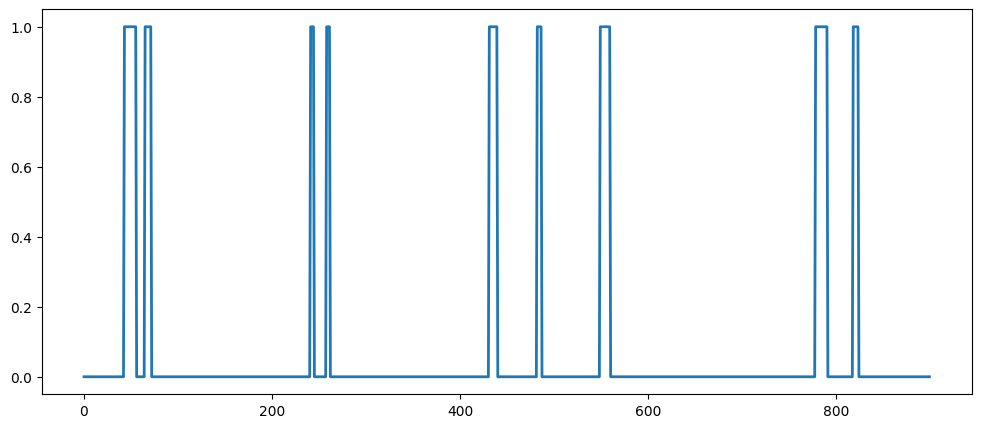

In [ ]:
# blink rate analysis

blink_pattern = sample_348_df["AU45_c"]
# plt.plot(blink_pattern,)
plt.figure(figsize=(12,5))

plt.plot(
    np.arange(len(blink_pattern[10000:10900])),
    blink_pattern[10000:10900],
    # marker='o',
    linewidth=2
)

In [ ]:
sample_349_df = pd.read_csv(f"{DATA_DIR}/349_nprocessed.csv")
sample_346_df = pd.read_csv(f"{DATA_DIR}/346_nprocessed.csv")



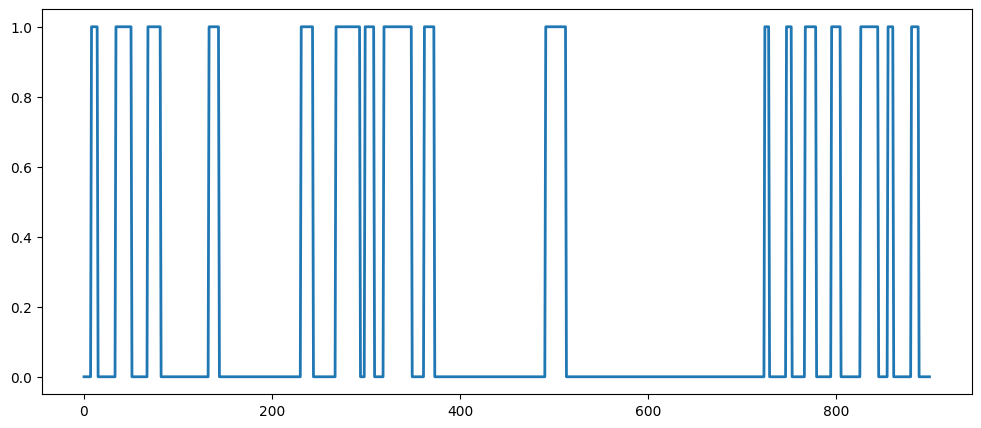

In [ ]:
blink_pattern = sample_349_df["AU45_c"]
# plt.plot(blink_pattern,)
plt.figure(figsize=(12,5))

plt.plot(
    np.arange(len(blink_pattern[10000:10900])),
    blink_pattern[10000:10900],
    # marker='o',
    linewidth=2
)

In [ ]:
# 1min window level blink patterns extraction:
# 1. calculate number of blink in the window
# 2. calculate the blink rate for each window
# 3. calculate avg. blink duration for each window
# For each 1-minute window:
import numpy as np
def blink_stats(df):
  fps = 30
  window_size = 60 * fps      # 1 minute = 1800 frames

  results = []

  for start in range(0, len(df), window_size):

      window = df.iloc[start:start + window_size]

      blink_count = 0
      blink_durations = []

      in_blink = False
      duration = 0

      for value in window["AU45_c"]:

          if value == 1:

              if not in_blink:
                  blink_count += 1
                  in_blink = True
                  duration = 1
              else:
                  duration += 1

          else:

              if in_blink:
                  blink_durations.append(duration)
                  in_blink = False
                  duration = 0

      # Blink continues until end of window
      if in_blink:
          blink_durations.append(duration)

      # Convert durations from frames to seconds
      blink_durations = np.array(blink_durations) / fps

      avg_duration = (
          blink_durations.mean()
          if len(blink_durations) > 0
          else 0
      )

      blink_rate = blink_count      # per minute

      results.append({
          "blink_count": blink_count,
          "blink_rate": blink_rate,
          "avg_duration": avg_duration
      })
  return results

In [ ]:
# phq:5
results_non_dep = blink_stats(sample_349_df)
results_non_dep = results_non_dep[int(0.10*len(results_non_dep)):int(0.90*len(results_non_dep))]
results_non_dep_2 = blink_stats(sample_300_df)
print(results_non_dep)

[{'blink_count': 23, 'blink_rate': 23, 'avg_duration': np.float64(0.7826086956521742)}, {'blink_count': 34, 'blink_rate': 34, 'avg_duration': np.float64(0.4980392156862744)}, {'blink_count': 37, 'blink_rate': 37, 'avg_duration': np.float64(0.36666666666666653)}, {'blink_count': 32, 'blink_rate': 32, 'avg_duration': np.float64(0.340625)}, {'blink_count': 36, 'blink_rate': 36, 'avg_duration': np.float64(0.37129629629629624)}, {'blink_count': 21, 'blink_rate': 21, 'avg_duration': np.float64(0.846031746031746)}, {'blink_count': 45, 'blink_rate': 45, 'avg_duration': np.float64(0.4607407407407408)}, {'blink_count': 34, 'blink_rate': 34, 'avg_duration': np.float64(1.2098039215686276)}, {'blink_count': 33, 'blink_rate': 33, 'avg_duration': np.float64(0.6616161616161615)}, {'blink_count': 37, 'blink_rate': 37, 'avg_duration': np.float64(0.6342342342342343)}, {'blink_count': 38, 'blink_rate': 38, 'avg_duration': np.float64(0.5868421052631579)}, {'blink_count': 28, 'blink_rate': 28, 'avg_duration

In [ ]:
# phq:20
results_dep = blink_stats(sample_348_df)
results_dep_2 = blink_stats(sample_346_df)
results_dep_2 = results_dep_2[int(0.10*len(results_dep_2)):int(0.90*len(results_dep_2))]
print(results_dep)

[{'blink_count': 22, 'blink_rate': 22, 'avg_duration': np.float64(0.781818181818182)}, {'blink_count': 29, 'blink_rate': 29, 'avg_duration': np.float64(0.3195402298850574)}, {'blink_count': 30, 'blink_rate': 30, 'avg_duration': np.float64(0.2955555555555555)}, {'blink_count': 29, 'blink_rate': 29, 'avg_duration': np.float64(0.4448275862068965)}, {'blink_count': 36, 'blink_rate': 36, 'avg_duration': np.float64(0.4407407407407408)}, {'blink_count': 14, 'blink_rate': 14, 'avg_duration': np.float64(0.3642857142857143)}, {'blink_count': 29, 'blink_rate': 29, 'avg_duration': np.float64(0.33218390804597697)}, {'blink_count': 27, 'blink_rate': 27, 'avg_duration': np.float64(0.6111111111111112)}, {'blink_count': 25, 'blink_rate': 25, 'avg_duration': np.float64(0.3413333333333333)}, {'blink_count': 24, 'blink_rate': 24, 'avg_duration': np.float64(0.6263888888888889)}, {'blink_count': 24, 'blink_rate': 24, 'avg_duration': np.float64(0.8569444444444444)}, {'blink_count': 28, 'blink_rate': 28, 'avg

In [ ]:
dep_counts = [r["blink_count"] for r in results_dep]
dep_counts_2 = [r["blink_count"] for r in results_dep_2]
control_counts = [r["blink_count"] for r in results_non_dep]
control_counts_2 = [r["blink_count"] for r in results_non_dep_2]


In [ ]:
avg_cnt = np.sum(dep_counts_2) / len(dep_counts_2)
avg_cnt

np.float64(30.5625)

In [ ]:
avg_cnt = np.sum(control_counts) / len(control_counts)
avg_cnt

np.float64(33.1875)

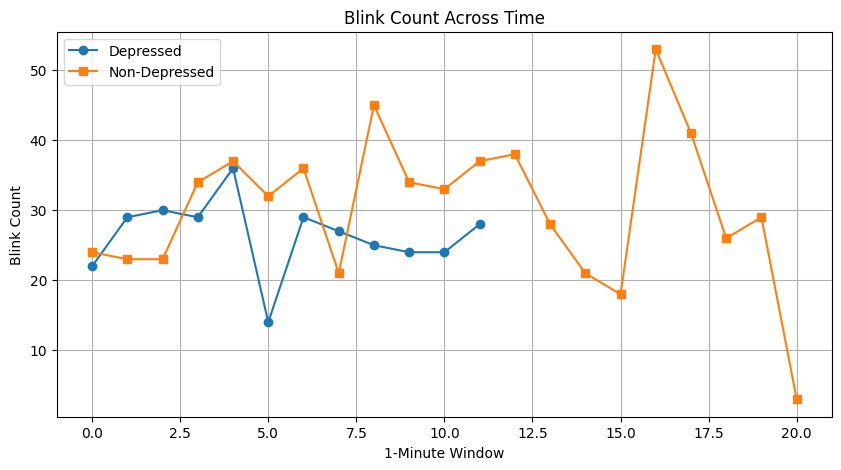

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(dep_counts, marker='o', label='Depressed')
plt.plot(control_counts, marker='s', label='Non-Depressed')

plt.xlabel("1-Minute Window")
plt.ylabel("Blink Count")
plt.title("Blink Count Across Time")
plt.legend()
plt.grid(True)

plt.show()

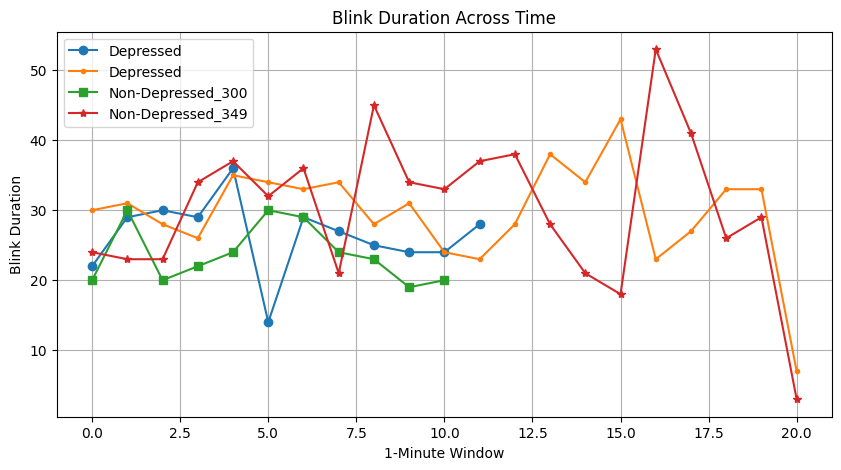

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(dep_counts, marker='o', label='Depressed')
plt.plot(dep_counts_2, marker='.', label='Depressed')
plt.plot(control_counts_2, marker='s', label='Non-Depressed_300')
plt.plot(control_counts, marker='*', label='Non-Depressed_349')

plt.xlabel("1-Minute Window")
plt.ylabel("Blink Duration")
plt.title("Blink Duration Across Time")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
BASE_DIR_2 = "/content/drive/MyDrive/edaic3.0"
session_ids_path = "/content/drive/MyDrive/edaic3.0/labels/Detailed_PHQ8_Labels.csv"
session_ids = pd.read_csv(session_ids_path)
session_ids = session_ids["Participant_ID"]
session_ids.head()

,Participant_ID
0,300
1,301
2,302
3,303
4,304


In [ ]:
# sample_300_df = pd.read_csv(f"{DATA_DIR}/300_nprocessed.csv")
final_blink_stats = []
for id in session_ids:
  results = []
  df = pd.read_csv(f"{BASE_DIR_2}/{id}/features/{id}_OpenFace2.1.0_Pose_gaze_AUs.csv")
  results = blink_stats(sample_348_df)
  results = results[int(0.10*len(results)):int(0.90*len(results))]
  final_blink_stats.append(results)


KeyboardInterrupt: 

In [ ]:
final_blink_stats

[[{'blink_count': 29,
   'blink_rate': 29,
   'avg_duration': np.float64(0.3195402298850574)},
  {'blink_count': 30,
   'blink_rate': 30,
   'avg_duration': np.float64(0.2955555555555555)},
  {'blink_count': 29,
   'blink_rate': 29,
   'avg_duration': np.float64(0.4448275862068965)},
  {'blink_count': 36,
   'blink_rate': 36,
   'avg_duration': np.float64(0.4407407407407408)},
  {'blink_count': 14,
   'blink_rate': 14,
   'avg_duration': np.float64(0.3642857142857143)},
  {'blink_count': 29,
   'blink_rate': 29,
   'avg_duration': np.float64(0.33218390804597697)},
  {'blink_count': 27,
   'blink_rate': 27,
   'avg_duration': np.float64(0.6111111111111112)},
  {'blink_count': 25,
   'blink_rate': 25,
   'avg_duration': np.float64(0.3413333333333333)},
  {'blink_count': 24,
   'blink_rate': 24,
   'avg_duration': np.float64(0.6263888888888889)}],
 [{'blink_count': 29,
   'blink_rate': 29,
   'avg_duration': np.float64(0.3195402298850574)},
  {'blink_count': 30,
   'blink_rate': 30,
   'a

In [ ]:
final_blink_stats.head()
final_blink_stats.to_csv("/content/drive/MyDrive/DAIC_WOZ_VIDEO_BRANCH/data/processed/blink_stats")

In [ ]:
for i in range(1,114):
  if()